In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/home-data-for-ml-course/sample_submission.csv
/kaggle/input/competitions/home-data-for-ml-course/sample_submission.csv.gz
/kaggle/input/competitions/home-data-for-ml-course/train.csv.gz
/kaggle/input/competitions/home-data-for-ml-course/data_description.txt
/kaggle/input/competitions/home-data-for-ml-course/test.csv.gz
/kaggle/input/competitions/home-data-for-ml-course/train.csv
/kaggle/input/competitions/home-data-for-ml-course/test.csv


In [2]:
train=pd.read_csv("/kaggle/input/competitions/home-data-for-ml-course/train.csv")
test=pd.read_csv("/kaggle/input/competitions/home-data-for-ml-course/test.csv")

<Axes: xlabel='SalePrice', ylabel='Count'>

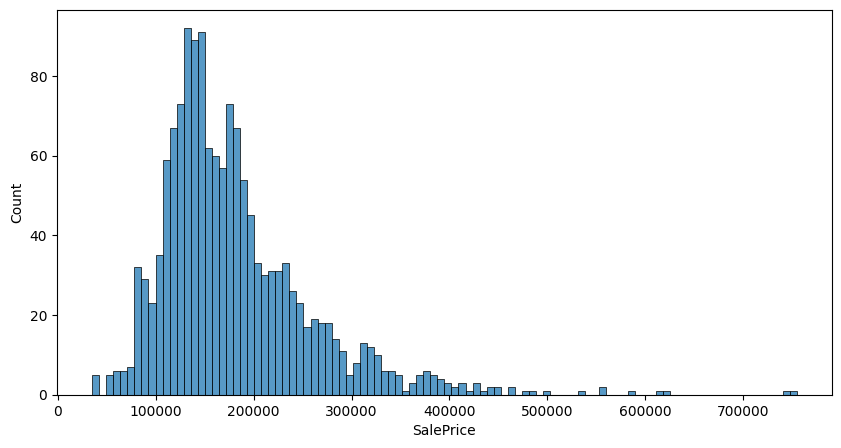

In [3]:
plt.figure(figsize=(10,5))
sns.histplot(train['SalePrice'], bins=100) 

In [4]:
target_row=train[train['SalePrice']>700000]
for i in target_row.index:
    context_row=train.iloc[i:i+10]
    print(context_row)

      Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
691  692          60       RL        104.0    21535   Pave   NaN      IR1   
692  693          60       RL         42.0    26178   Pave   NaN      IR1   
693  694          30       RL         60.0     5400   Pave   NaN      Reg   
694  695          50       RM         51.0     6120   Pave   NaN      Reg   
695  696          20       RL         54.0    13811   Pave   NaN      IR1   
696  697          30       RM         50.0     6000   Pave   NaN      Reg   
697  698          20       RL         57.0     6420   Pave   NaN      IR1   
698  699          20       RL         65.0     8450   Pave   NaN      Reg   
699  700         120       FV         59.0     4282   Pave  Pave      IR2   
700  701          20       RL         85.0    14331   Pave   NaN      Reg   

    LandContour Utilities  ... PoolArea PoolQC  Fence MiscFeature MiscVal  \
691         Lvl    AllPub  ...        0    NaN    NaN         NaN       0  

In [5]:
print(len(train))
train= train[train['SalePrice'] <= 600000]
print(len(train))

1460
1456


In [6]:
train_clean=train.drop_duplicates()
print(len(train))

1456


In [7]:
train_clean['Qual_bin'] = pd.cut(
    train_clean['OverallQual'],
    bins=[0, 4, 7, 10],
    labels=['低质量', '中质量', '高质量']
).astype(str)
# 交叉特征：地段+质量
train_clean['Neighborhood_Qual'] = train_clean['Neighborhood'] + '_' + train_clean['Qual_bin']

In [8]:
train_clean['GrLivArea_bin'] = pd.cut(
    train_clean['GrLivArea'],
    bins=[0, 1000, 2000, 5000],
    labels=['小户型', '中户型', '大户型']
).astype(str)
# 交叉特征：地段+户型
train_clean['Neighborhood_GrLiv'] = train_clean['Neighborhood'] + '_' + train_clean['GrLivArea_bin']

In [9]:
train_clean['Bsmt_bin'] = pd.cut(
    train_clean['TotalBsmtSF'],
    bins=[-1, 0, 1000, 5000],  # -1避免0被归到0-1000
    labels=['无地下室', '小地下室', '大地下室']
).astype(str)
# 交叉特征：户型+地下室
train_clean['HouseStyle_Bsmt'] = train_clean['HouseStyle'] + '_' + train_clean['Bsmt_bin']

In [10]:
# 1. 计算每个特征的缺失值数量
missing_count = train_clean.isnull().sum().sort_values(ascending=False)

# 2. 计算每个特征的缺失值比例
missing_ratio = (train_clean.isnull().sum() / len(train_clean)).sort_values(ascending=False)

# 3. 把结果拼成一个表格，方便看
missing_info = pd.DataFrame({
    '缺失数量': missing_count,
    '缺失比例': missing_ratio
})

# 4. 只显示有缺失的特征（缺失数量>0的）
print("有缺失值的特征：")
print(missing_info[missing_info['缺失数量'] > 0])

有缺失值的特征：
              缺失数量      缺失比例
PoolQC        1450  0.995879
MiscFeature   1402  0.962912
Alley         1365  0.937500
Fence         1176  0.807692
MasVnrType     871  0.598214
FireplaceQu    690  0.473901
LotFrontage    259  0.177885
GarageCond      81  0.055632
GarageType      81  0.055632
GarageFinish    81  0.055632
GarageYrBlt     81  0.055632
GarageQual      81  0.055632
BsmtFinType2    38  0.026099
BsmtExposure    38  0.026099
BsmtCond        37  0.025412
BsmtFinType1    37  0.025412
BsmtQual        37  0.025412
MasVnrArea       8  0.005495
Electrical       1  0.000687


In [11]:
# ===================== 处理缺失值 =====================
# 1. 缺失 > 80% 的列，直接删除（几乎全空，没用）
drop_cols = [
    'PoolQC',      # 泳池质量（99.5%缺失）
    'MiscFeature', # 额外设施（96%缺失）
    'Alley',       # 小巷类型（93%缺失）
    'Fence'        # 围栏（80%缺失）
]
train_clean = train_clean.drop(columns=drop_cols, axis=1)

# 2. 缺失 10%~60% 的列 → 填充为 "None"（代表“没有这个东西”）
none_cols = [
    'MasVnrType', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtFinType1', 'BsmtFinType2', 'BsmtExposure', 'BsmtCond', 'BsmtQual'
]
for col in none_cols:
    train_clean[col] = train_clean[col].fillna("None")

# 3. 数值型缺失 → 用中位数填充
train_clean['LotFrontage'] = train_clean['LotFrontage'].fillna(train_clean['LotFrontage'].median())
train_clean['MasVnrArea'] = train_clean['MasVnrArea'].fillna(0)
train_clean['GarageYrBlt'] = train_clean['GarageYrBlt'].fillna(0)

# 4. 最后 1 个缺失（电气系统）→ 用众数填充
train_clean['Electrical'] = train_clean['Electrical'].fillna(train_clean['Electrical'].mode()[0])

In [12]:
missing = train_clean.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

Series([], dtype: int64)


In [13]:
# 目标：预测房价 SalePrice
y = train_clean['SalePrice']

# 特征：所有其他列（去掉ID、去掉SalePrice）
X = train_clean.drop(['Id', 'SalePrice'], axis=1)

In [14]:
# 找出所有是文字的列
object_cols = X.select_dtypes(include=['object']).columns

# 对文字列做 OneHot 编码（变成数字）
from sklearn.preprocessing import OneHotEncoder
transformer = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), object_cols)
    ],
    remainder='passthrough'
)

# 把 X 全部变成数字
X_encoded = transformer.fit_transform(X)

In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

In [16]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=1000, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [17]:
pred = model.predict(X_val)
mae = mean_absolute_error(y_val, pred)
print("验证集 MAE:", mae)

验证集 MAE: 14886.318359375


In [18]:
# ===================== 处理测试集 =====================
# 1. 先做和训练集一样的特征工程
test_clean = test.copy()

# 删同样的列
test_clean = test_clean.drop(columns=drop_cols, axis=1)

# 填充缺失值（和训练集完全一样）
for col in none_cols:
    test_clean[col] = test_clean[col].fillna("None")

test_clean['LotFrontage'] = test_clean['LotFrontage'].fillna(train_clean['LotFrontage'].median())
test_clean['MasVnrArea'] = test_clean['MasVnrArea'].fillna(0)
test_clean['GarageYrBlt'] = test_clean['GarageYrBlt'].fillna(0)
test_clean['Electrical'] = test_clean['Electrical'].fillna(train_clean['Electrical'].mode()[0])

# 做同样的特征工程（分箱+交叉特征）
test_clean['Qual_bin'] = pd.cut(
    test_clean['OverallQual'],
    bins=[0, 4, 7, 10],
    labels=['低质量', '中质量', '高质量']
).astype(str)
test_clean['Neighborhood_Qual'] = test_clean['Neighborhood'] + '_' + test_clean['Qual_bin']

test_clean['GrLivArea_bin'] = pd.cut(
    test_clean['GrLivArea'],
    bins=[0, 1000, 2000, 5000],
    labels=['小户型', '中户型', '大户型']
).astype(str)
test_clean['Neighborhood_GrLiv'] = test_clean['Neighborhood'] + '_' + test_clean['GrLivArea_bin']

test_clean['Bsmt_bin'] = pd.cut(
    test_clean['TotalBsmtSF'],
    bins=[-1, 0, 1000, 5000],
    labels=['无地下室', '小地下室', '大地下室']
).astype(str)
test_clean['HouseStyle_Bsmt'] = test_clean['HouseStyle'] + '_' + test_clean['Bsmt_bin']

# 2. 用训练集的 transformer 编码测试集（注意：用 transform，不是 fit_transform！）
X_test = test_clean.drop(['Id'], axis=1)
X_test_encoded = transformer.transform(X_test)

In [19]:
# 1. 用训练好的模型预测测试集
test_pred = model.predict(X_test_encoded)

# 2. 生成 Kaggle 要求的提交格式
submission = pd.DataFrame({
    'Id': test['Id'],
    'SalePrice': test_pred
})

# 3. 保存为 CSV 文件
submission.to_csv('submission.csv', index=False)

print("提交文件已生成！")

提交文件已生成！
